# 01_StandardScaler.ipynb

---

# 1. Why Do We Need Feature Scaling?

Suppose we have this dataset.

| Age | Salary |
| --- | -----: |
| 20  |  25000 |
| 25  |  30000 |
| 35  |  80000 |
| 45  | 120000 |

Notice the ranges.

* Age → **20–45**
* Salary → **25,000–120,000**

Salary values are **thousands of times larger** than age.

Many ML algorithms use **distance**, **gradients**, or **optimization**. Larger-valued features dominate smaller-valued ones.

Example

Without scaling

```
Age    = 25
Salary = 100000
```

The algorithm mainly "sees" Salary because its magnitude is much larger.

This can lead to

* Slow convergence
* Poor optimization
* Incorrect feature importance
* Numerical instability

Scaling puts every feature on approximately the same scale.

---

# 2. What is StandardScaler?

StandardScaler transforms every feature so that

* Mean = 0
* Standard Deviation = 1

After scaling

| Feature | Mean | Std |
| ------- | ---- | --- |
| Age     | 0    | 1   |
| Salary  | 0    | 1   |

The actual values change, but the information remains the same.

---

# 3. Formula

For every value

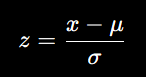

where

* x = original value
* μ = feature mean
* σ = feature standard deviation

This is called the **Z-score**.

---

# Example

Age column

```
20
25
30
35
40
```

Mean

```
30
```

Standard deviation

```
7.07
```

Age = 20

```
(20-30)/7.07

≈ -1.41
```

Age = 40

```
(40-30)/7.07

≈ +1.41
```

The transformed column becomes approximately

```
-1.41
-0.71
0
0.71
1.41
```

Notice

Mean

```
0
```

Standard deviation

```
1
```

---

# 4. What Actually Changes?

Only the numerical representation changes.

Before

```
Age

20
25
30
35
40
```

After

```
-1.41
-0.71
0
0.71
1.41
```

The order of data does **not** change.

Largest value is still the largest.

Smallest is still the smallest.

Relationships remain the same.

---

# 5. Distribution After Scaling

StandardScaler **does not make data normally distributed**.

It only

* subtracts the mean
* divides by the standard deviation

If data was skewed before,

it remains skewed afterward.

Many beginners incorrectly think StandardScaler "normalizes" the distribution. It does not.

---

# 6. Mean = 0

Suppose

```
10
20
30
40
50
```

Mean

```
30
```

Subtract mean

```
-20
-10
0
10
20
```

Average

```
0
```

That is why scaled data has mean 0.

---

# 7. Standard Deviation = 1

After subtracting the mean,

divide every value by the original standard deviation.

This rescales the spread so that one standard deviation equals **1**.

---

# 8. When Should We Use StandardScaler?

Use when the algorithm depends on

* distance
* gradients
* optimization
* variance

Examples

✅ Linear Regression (especially with regularization)

✅ Logistic Regression

✅ SVM

✅ KNN

✅ Neural Networks

✅ PCA

✅ K-Means

---

# 9. Algorithms That Usually Don't Need Scaling

Tree-based models split on feature values rather than distances or gradients.

Examples

* Decision Tree
* Random Forest
* Extra Trees
* XGBoost
* LightGBM
* CatBoost

Scaling usually has little or no effect on these algorithms.

---

# 10. Advantages

* Faster gradient descent
* Stable optimization
* Prevents large-valued features from dominating
* Improves convergence
* Essential for many algorithms

---

# 11. Disadvantages

* Sensitive to outliers
* Doesn't make data Gaussian
* Harder to interpret transformed values
* Requires storing mean and standard deviation for future data

---

# 12. StandardScaler vs Normalization

These are different concepts.

**Standardization (StandardScaler):**

* Mean becomes 0
* Standard deviation becomes 1
* Values are unbounded (can be less than 0 or greater than 1)

**Normalization (MinMaxScaler):**

* Values are scaled to a fixed range (typically 0 to 1)
* Preserves relative distances within that range
* Sensitive to outliers

---

# 13. StandardScaler vs MinMaxScaler

| Feature  | StandardScaler                            | MinMaxScaler                                              |
| -------- | ----------------------------------------- | --------------------------------------------------------- |
| Formula  | (x − mean) / std                          | (x − min) / (max − min)                                   |
| Mean     | 0                                         | Not fixed                                                 |
| Std      | 1                                         | Not fixed                                                 |
| Range    | Unbounded                                 | Usually 0–1                                               |
| Outliers | Affected                                  | More affected                                             |
| Best for | Regression, SVM, Logistic Regression, PCA | Neural Networks (sometimes), bounded feature requirements |

---

# Summary

By the end of this section, you should understand:

* Why feature scaling is necessary
* The mathematical intuition behind StandardScaler
* The Z-score formula
* Why scaled data has mean 0 and standard deviation 1
* Which algorithms require scaling and which generally do not
* The difference between StandardScaler and MinMaxScaler

## 02. Import

---

### Importing StandardScaler

```python
from sklearn.preprocessing import StandardScaler
```

This imports the `StandardScaler` class from the `sklearn.preprocessing` module.

---

### Why is it inside `preprocessing`?

Scikit-learn is divided into modules based on functionality.

| Module                  | Purpose                                          |
| ----------------------- | ------------------------------------------------ |
| sklearn.preprocessing   | Data preprocessing                               |
| sklearn.model_selection | Train-test split, Cross Validation, GridSearchCV |
| sklearn.linear_model    | Linear & Logistic Regression                     |
| sklearn.tree            | Decision Trees                                   |
| sklearn.ensemble        | Random Forest, Gradient Boosting                 |
| sklearn.metrics         | Evaluation Metrics                               |
| sklearn.pipeline        | Pipelines                                        |

Since StandardScaler modifies data before training, it belongs to the preprocessing module.

---

### Creating the Object

```python
scaler = StandardScaler()
```

Nothing happens yet.

No scaling is performed.

No mean is calculated.

No standard deviation is calculated.

Only an empty object is created.

Think of it as creating an empty calculator.

---

# 03. Constructor Parameters

Syntax

```python
StandardScaler(
    *,
    copy=True,
    with_mean=True,
    with_std=True
)
```

Only **3 constructor parameters**, but understanding them properly is important.

---

# Parameter 1 : copy

Default

```python
copy=True
```

### Purpose

Controls whether the original dataset is modified.

---

## copy=True (Default)

```python
scaler = StandardScaler(copy=True)
```

Creates a **new scaled array**.

Original data remains unchanged.

Example

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "Age":[20,25,30],
    "Salary":[30000,40000,50000]
})

scaler = StandardScaler(copy=True)

scaled = scaler.fit_transform(df)
```

Now

```python
df
```

```
Age   Salary
20    30000
25    40000
30    50000
```

unchanged.

while

```python
scaled
```

contains the transformed values.

---

## copy=False

```python
scaler = StandardScaler(copy=False)
```

Scikit-learn **tries** to modify the input array directly instead of creating another copy.

Advantages

* Lower memory usage
* Faster for huge datasets

Disadvantages

* Original array may change.
* In-place modification is **not always guaranteed**. If the input format doesn't support it (for example, some pandas objects or read-only arrays), scikit-learn may still create a copy internally.

---

### When should you use it?

| Dataset        | Recommendation                        |
| -------------- | ------------------------------------- |
| Small / Medium | `copy=True`                           |
| Very Large     | `copy=False` (if memory is important) |

For almost every ML project you'll write,

```python
copy=True
```

is the safest choice.

---

# Parameter 2 : with_mean

Default

```python
with_mean=True
```

### Purpose

Determines whether the feature mean should be subtracted.

Recall the formula

[
z=\frac{x-\mu}{\sigma}
]

The first step is

```text
x − mean
```

This parameter controls that step.

---

## with_mean=True

Suppose

```python
Age

20
25
30
35
40
```

Mean

```python
30
```

Subtract mean

```python
-10
-5
0
5
10
```

Then divide by the standard deviation.

Final scaled values

```python
-1.41
-0.71
0
0.71
1.41
```

Mean becomes

```python
0
```

This is standard behavior.

---

## with_mean=False

```python
scaler = StandardScaler(with_mean=False)
```

Now the mean is **not subtracted**.

Only division by the standard deviation happens.

Formula becomes

[
z=\frac{x}{\sigma}
]

Notice

Mean is **not zero anymore**.

---

### Why would anyone use this?

Main reason:

### Sparse Matrices

Many NLP and recommendation-system datasets are stored as sparse matrices.

Example

```text
0 0 0 2 0 0
0 0 5 0 0 0
0 7 0 0 0 0
```

If we subtract the mean,

almost every zero becomes a non-zero value.

The sparse matrix becomes dense, consuming much more memory.

Therefore, for sparse matrices:

```python
StandardScaler(with_mean=False)
```

is commonly used.

---

### When should you use it?

| Data Type           | Recommendation    |
| ------------------- | ----------------- |
| Normal tabular data | `with_mean=True`  |
| Sparse matrices     | `with_mean=False` |

---

# Parameter 3 : with_std

Default

```python
with_std=True
```

### Purpose

Controls whether values are divided by the standard deviation.

---

## with_std=True

Formula

[
z=\frac{x-\mu}{\sigma}
]

This is normal StandardScaler behavior.

Result

* Mean = 0
* Standard deviation = 1

---

## with_std=False

```python
scaler = StandardScaler(with_std=False)
```

Formula becomes

[
z=x-\mu
]

Only centering happens.

Example

Original

```python
20
25
30
35
40
```

Subtract mean

```python
-10
-5
0
5
10
```

No division occurs.

Standard deviation is **not** equal to 1.

---

### When is this useful?

Rarely.

Mostly for research or algorithms that require only centering.

For almost all practical ML projects:

```python
with_std=True
```

is used.

---

# Constructor Summary

| Parameter | Default | Purpose                       | Typical Usage                            |
| --------- | ------- | ----------------------------- | ---------------------------------------- |
| copy      | True    | Create a separate scaled copy | Keep `True`                              |
| with_mean | True    | Subtract feature mean         | Keep `True` unless using sparse matrices |
| with_std  | True    | Divide by standard deviation  | Keep `True`                              |

---

## Interview Questions

### Q1. How many constructor parameters does StandardScaler have?

**Answer:** Three.

* `copy`
* `with_mean`
* `with_std`

---

### Q2. Why is `with_mean=False` used with sparse matrices?

Because subtracting the mean converts many zero values into non-zero values, making the sparse matrix dense and greatly increasing memory usage.

---

### Q3. Does `copy=False` always modify the original dataset?

No. It **attempts** to perform in-place scaling, but if the input format does not support it, scikit-learn may still create a copy internally.

---

That completes the **Import & Constructor Parameters** section.

Next we'll cover **Methods**, where we'll go deep into:

* `fit()`
* `transform()`
* `fit_transform()`
* `inverse_transform()`
* `get_feature_names_out()`
* `get_metadata_routing()`
* `set_output()`

including what each method does internally, when to use it, return values, and common mistakes.


# 01_StandardScaler.ipynb

# 04. Methods

---

## What are Methods?

Methods are functions that belong to the `StandardScaler` object.

Example

```python
scaler = StandardScaler()
```

Now `scaler` has several methods like

```python
scaler.fit()
scaler.transform()
scaler.fit_transform()
scaler.inverse_transform()
```

Each performs a different task.

---

# Overview

| Method                  | Purpose                     | Learns? | Transforms? |
| ----------------------- | --------------------------- | ------- | ----------- |
| fit()                   | Learn mean & std            | ✅       | ❌           |
| transform()             | Scale data                  | ❌       | ✅           |
| fit_transform()         | Learn + Scale               | ✅       | ✅           |
| inverse_transform()     | Recover original values     | ❌       | ✅           |
| get_feature_names_out() | Return feature names        | ❌       | ❌           |
| get_metadata_routing()  | Metadata routing (advanced) | ❌       | ❌           |
| set_output()            | Set output format           | ❌       | ❌           |

---

# Method 1 : fit()

Syntax

```python
scaler.fit(X)
```

---

## Purpose

Computes the statistics required for scaling.

It learns

* Mean
* Standard Deviation
* Variance

It **does not** modify the dataset.

---

### Example

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "Age":[20,25,30,35,40]
})

scaler = StandardScaler()

scaler.fit(df)
```

Dataset remains

```text
20
25
30
35
40
```

Nothing changes.

Internally, StandardScaler stores

```text
Mean = 30

Standard deviation = 7.07
```

---

### What happens internally?

Step 1

Calculate mean

```python
30
```

↓

Step 2

Calculate variance

↓

Step 3

Calculate standard deviation

↓

Store these values inside the object.

That's all.

---

### Return Value

```python
scaler.fit(df)
```

returns

```python
StandardScaler()
```

because the object itself is returned.

This allows method chaining.

---

### Common Mistake

Many beginners think

```python
scaler.fit(df)
```

returns scaled data.

It does **not**.

---

# Method 2 : transform()

Syntax

```python
scaler.transform(X)
```

---

## Purpose

Uses the statistics learned during `fit()` to scale new data.

It never recalculates the mean or standard deviation.

---

Example

```python
scaler.fit(df)

scaled = scaler.transform(df)
```

Now scaling happens.

Output

```text
-1.41
-0.71
0
0.71
1.41
```

---

### Internal Working

Uses

```text
Stored Mean

Stored Standard Deviation
```

Formula

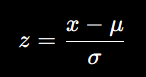

No learning occurs.

---

### Important Rule

Always

```python
Fit

↓

Transform
```

Never

```python
Transform

↓

Fit
```

because `transform()` requires statistics already computed by `fit()`.

---

### Common Error

```python
scaler = StandardScaler()

scaler.transform(df)
```

Error

```text
NotFittedError
```

because nothing has been learned.

---

# Method 3 : fit_transform()

Syntax

```python
scaled = scaler.fit_transform(df)
```

---

## Purpose

Performs

```text
fit()

↓

transform()
```

in one step.

Equivalent to

```python
scaler.fit(df)

scaled = scaler.transform(df)
```

---

### Why use it?

Less code

Faster

Cleaner

---

### Internal Working

```text
Learn Mean

↓

Learn Standard Deviation

↓

Scale Data

↓

Return scaled data
```

---

### When should we use it?

Training data

```python
X_train_scaled = scaler.fit_transform(X_train)
```

Testing data

Never

```python
scaler.fit_transform(X_test)
```

Instead

```python
X_test_scaled = scaler.transform(X_test)
```

---

### Why?

If you fit again,

new mean and std are computed from test data.

This causes **data leakage**.

---

### Correct Workflow

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
```

This is one of the most important preprocessing rules in machine learning.

---

# Method 4 : inverse_transform()

Syntax

```python
original = scaler.inverse_transform(scaled_data)
```

---

## Purpose

Converts scaled values back into their original values.

Formula

From

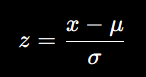

Recover

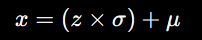

---

### Example

Scaled values

```text
-1.41
-0.71
0
0.71
1.41
```

After

```python
scaler.inverse_transform(scaled)
```

Output

```text
20
25
30
35
40
```

---

### When is this useful?

Examples

* Showing predictions in original units
* Restoring readable data
* Model interpretation
* Visualization

---

# Method 5 : get_feature_names_out()

Syntax

```python
scaler.get_feature_names_out()
```

---

### Purpose

Returns output feature names.

Example

```python
df.columns
```

```text
Age
Salary
Height
```

Result

```python
array(['Age','Salary','Height'])
```

Unlike OneHotEncoder, StandardScaler does **not** create new features.

Therefore names remain unchanged.

---

# Method 6 : get_metadata_routing()

Introduced in newer versions of scikit-learn.

Used internally for metadata routing between estimators and pipelines.

You generally won't use this in day-to-day machine learning.

---

# Method 7 : set_output()

Syntax

```python
scaler.set_output(transform="pandas")
```

---

### Purpose

Controls the type of object returned by `transform()`.

Default

```python
NumPy Array
```

Example

```python
scaler.set_output(transform="pandas")
```

Now

```python
scaler.fit_transform(df)
```

returns

```text
Pandas DataFrame
```

instead of a NumPy array.

This is useful because column names are preserved.

---

# Which methods do you actually use?

| Method                  | Frequency |
| ----------------------- | --------- |
| fit()                   | ⭐⭐⭐⭐⭐     |
| transform()             | ⭐⭐⭐⭐⭐     |
| fit_transform()         | ⭐⭐⭐⭐⭐     |
| inverse_transform()     | ⭐⭐⭐       |
| get_feature_names_out() | ⭐⭐        |
| set_output()            | ⭐⭐        |
| get_metadata_routing()  | ⭐         |
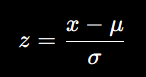

# 01_StandardScaler.ipynb

# 05. Attributes

---

# What are Attributes?

Attributes are variables that are automatically created **after calling `fit()`**.

They store the information learned from the training data.

Unlike methods,

```python
scaler.fit()
```

is something you **call**,

whereas

```python
scaler.mean_
```

is something you **access**.

---

## Important Rule

Attributes are created **only after `fit()`**.

Example

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.mean_
```

Output

```text
AttributeError
```

or

```text
NotFittedError
```

because the scaler hasn't learned anything yet.

Correct

```python
scaler.fit(X)

scaler.mean_
```

Now the attribute exists.

---

# Overview

| Attribute         | Purpose                                 |
| ----------------- | --------------------------------------- |
| mean_             | Mean of each feature                    |
| scale_            | Standard deviation used for scaling     |
| var_              | Variance of each feature                |
| n_features_in_    | Number of input features                |
| feature_names_in_ | Original feature names (DataFrame only) |

---

## **Example Workflow**

In [5]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(
    X_train_scaled,
    y_train
)

predictions = model.predict(
    X_test_scaled
)

accuracy = accuracy_score( y_test , predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 93.33%


| Mistake                                                 | Why You Shouldn't Do It                                                                                     |
| ------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| Calling `transform()` before `fit()`                    | The scaler hasn't learned the mean and standard deviation yet, so it cannot scale the data.                 |
| Using `fit_transform()` on the test data                | Computes new statistics from the test set, causing **data leakage** and inconsistent preprocessing.         |
| Scaling before Train-Test Split                         | The scaler learns information from the entire dataset, including the test set, leading to **data leakage**. |
| Using different scalers for training and testing        | Each scaler learns different statistics, so training and test data end up on different scales.              |
| Forgetting to scale new/unseen data before prediction   | The model was trained on scaled features, so predictions on unscaled data may be inaccurate.                |
| Scaling the target variable (`y`) unintentionally       | StandardScaler is generally applied only to input features (`X`), not the target variable.                  |
| Expecting values between 0 and 1                        | StandardScaler standardizes data (mean = 0, std = 1); it does **not** normalize data to a fixed range.      |
| Assuming StandardScaler removes outliers                | It only rescales the data; outliers remain and can still influence the transformed values.                  |
| Assuming StandardScaler makes data normally distributed | It changes the scale of the data but does not change the underlying distribution.                           |
